In [1]:
# Importing libraries for data analysis and visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the unemployment dataset
df = pd.read_csv("Unemployment_Rate_upto_11_2020.csv")

# Display the first five records
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


In [3]:
# Remove unnecessary spaces from column names
df.columns = df.columns.str.strip()

# Display column names
print(df.columns.tolist())

['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Region.1', 'longitude', 'latitude']


In [4]:
# Display number of rows and columns
print("Dataset Shape:", df.shape)

# Display data types
print("\nData Types:")
print(df.dtypes)

Dataset Shape: (267, 9)

Data Types:
Region                                      object
Date                                        object
Frequency                                   object
Estimated Unemployment Rate (%)            float64
Estimated Employed                           int64
Estimated Labour Participation Rate (%)    float64
Region.1                                    object
longitude                                  float64
latitude                                   float64
dtype: object


In [5]:
# Check missing values in each column
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Region.1                                   0
longitude                                  0
latitude                                   0
dtype: int64


In [6]:
# Remove rows containing missing values
df = df.dropna().copy()

print("Shape after removing missing values:", df.shape)

Shape after removing missing values: (267, 9)


In [7]:
# Convert Date column into datetime format
df["Date"] = pd.to_datetime(
    df["Date"],
    dayfirst=True,
    errors="coerce"
)

# Check the converted values
df[["Date"]].head()

,Date
0,2020-01-31
1,2020-02-29
2,2020-03-31
3,2020-04-30
4,2020-05-31


In [8]:
print(df["Date"].dtype)

datetime64[ns]


In [9]:
# Generate descriptive statistics for numerical columns
df.describe()

,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),longitude,latitude
count,267,267.000000,2.670000e+02,267.000000,267.000000,267.000000
mean,2020-06-16 09:15:30.337078528,12.236929,1.396211e+07,41.681573,22.826048,80.532425
min,2020-01-31 00:00:00,0.500000,1.175420e+05,16.770000,10.850500,71.192400
25%,2020-03-31 00:00:00,4.845000,2.838930e+06,37.265000,18.112400,76.085600
50%,2020-06-30 00:00:00,9.650000,9.732417e+06,40.390000,23.610200,79.019300
75%,2020-08-31 00:00:00,16.755000,2.187869e+07,44.055000,27.278400,85.279900
max,2020-10-31 00:00:00,75.850000,5.943376e+07,69.690000,33.778200,92.937600
std,NaN,10.803283,1.336632e+07,7.845419,6.270731,5.831738


In [10]:
# Calculate average unemployment rate for each region
region_avg = (
    df.groupby("Region")["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_values(ascending=False)
)

# Display the results
region_avg

Region
Haryana             27.477000
Tripura             25.055000
Jharkhand           19.539000
Bihar               19.471000
Delhi               18.414000
Puducherry          17.942000
Jammu & Kashmir     16.477778
Himachal Pradesh    16.065000
Rajasthan           15.868000
Tamil Nadu          12.187000
Goa                 12.167000
Punjab              11.981000
Uttarakhand         11.156000
West Bengal         10.192000
Sikkim               9.792500
Uttar Pradesh        9.737000
Kerala               9.434000
Andhra Pradesh       8.664000
Maharashtra          7.979000
Chhattisgarh         7.819000
Karnataka            7.668000
Madhya Pradesh       6.854000
Telangana            6.833000
Odisha               6.462000
Gujarat              6.376000
Assam                4.856000
Meghalaya            3.866000
Name: Estimated Unemployment Rate (%), dtype: float64

In [11]:
# Create a month-year column
df["Month"] = df["Date"].dt.to_period("M")

# Calculate average unemployment rate for each month
monthly_avg = (
    df.groupby("Month")["Estimated Unemployment Rate (%)"]
    .mean()
)

# Convert period back to timestamp for plotting
monthly_avg.index = monthly_avg.index.to_timestamp()

monthly_avg

Month
2020-01-01     9.196538
2020-02-01     9.266154
2020-03-01    10.782593
2020-04-01    22.236154
2020-05-01    23.244444
2020-06-01    10.911111
2020-07-01     9.834444
2020-08-01    10.313333
2020-09-01     8.705926
2020-10-01     8.026296
Freq: MS, Name: Estimated Unemployment Rate (%), dtype: float64

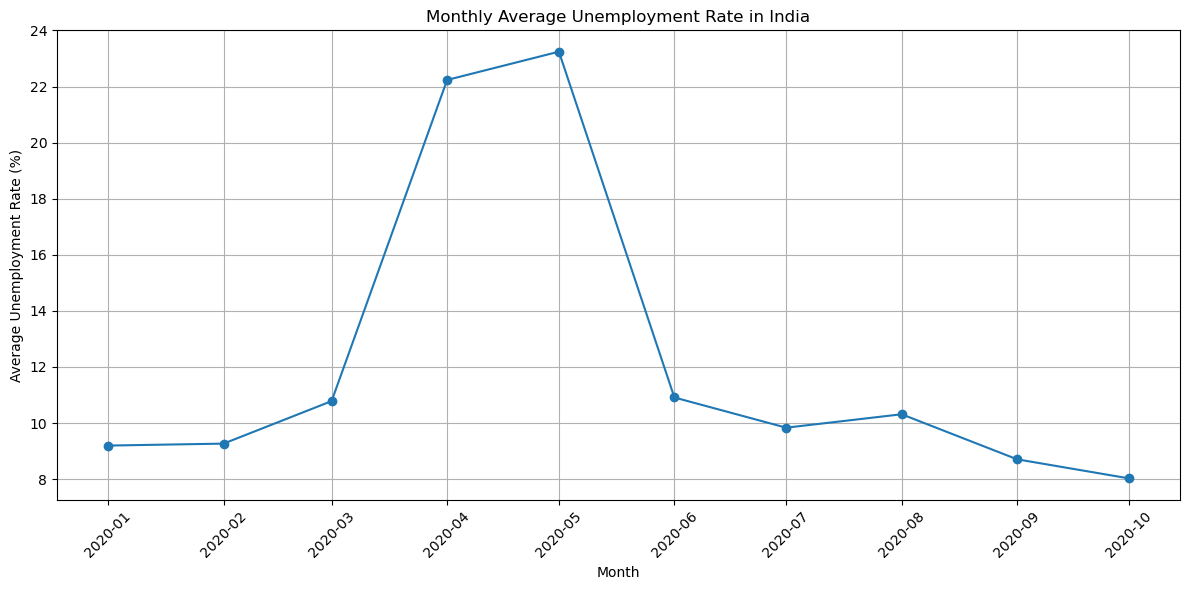

In [12]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_avg.index,
    monthly_avg.values,
    marker="o"
)

plt.title("Monthly Average Unemployment Rate in India")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

In [13]:
# Display available regions
sorted(df["Region"].unique())

['Andhra Pradesh',
 'Assam',
 'Bihar',
 'Chhattisgarh',
 'Delhi',
 'Goa',
 'Gujarat',
 'Haryana',
 'Himachal Pradesh',
 'Jammu & Kashmir',
 'Jharkhand',
 'Karnataka',
 'Kerala',
 'Madhya Pradesh',
 'Maharashtra',
 'Meghalaya',
 'Odisha',
 'Puducherry',
 'Punjab',
 'Rajasthan',
 'Sikkim',
 'Tamil Nadu',
 'Telangana',
 'Tripura',
 'Uttar Pradesh',
 'Uttarakhand',
 'West Bengal']

In [14]:
selected_states = [
    "Maharashtra",
    "Tamil Nadu",
    "Karnataka"
]

state_data = df[df["Region"].isin(selected_states)]

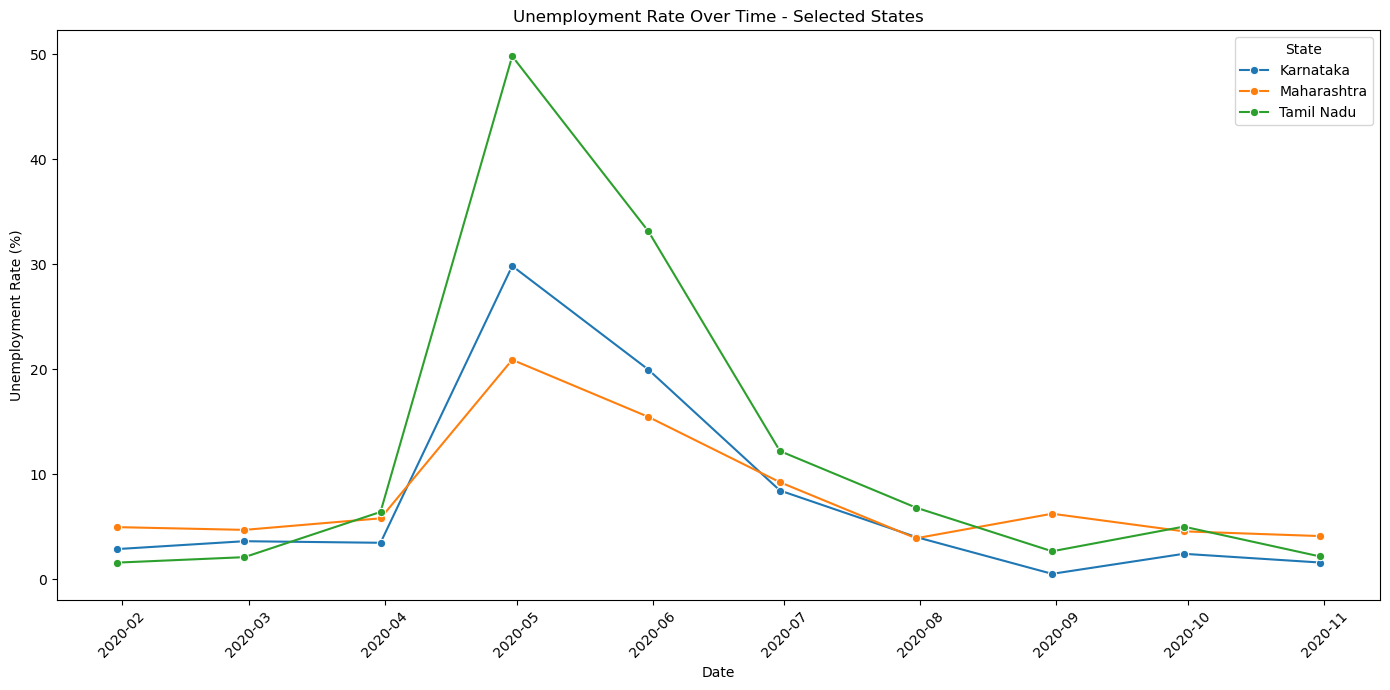

In [15]:
plt.figure(figsize=(14, 7))

sns.lineplot(
    data=state_data,
    x="Date",
    y="Estimated Unemployment Rate (%)",
    hue="Region",
    marker="o"
)

plt.title("Unemployment Rate Over Time - Selected States")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.legend(title="State")

plt.tight_layout()
plt.show()

In [16]:
# Calculate average unemployment rate by region
top_10_states = (
    df.groupby("Region")["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_10_states

Region
Haryana             27.477000
Tripura             25.055000
Jharkhand           19.539000
Bihar               19.471000
Delhi               18.414000
Puducherry          17.942000
Jammu & Kashmir     16.477778
Himachal Pradesh    16.065000
Rajasthan           15.868000
Tamil Nadu          12.187000
Name: Estimated Unemployment Rate (%), dtype: float64

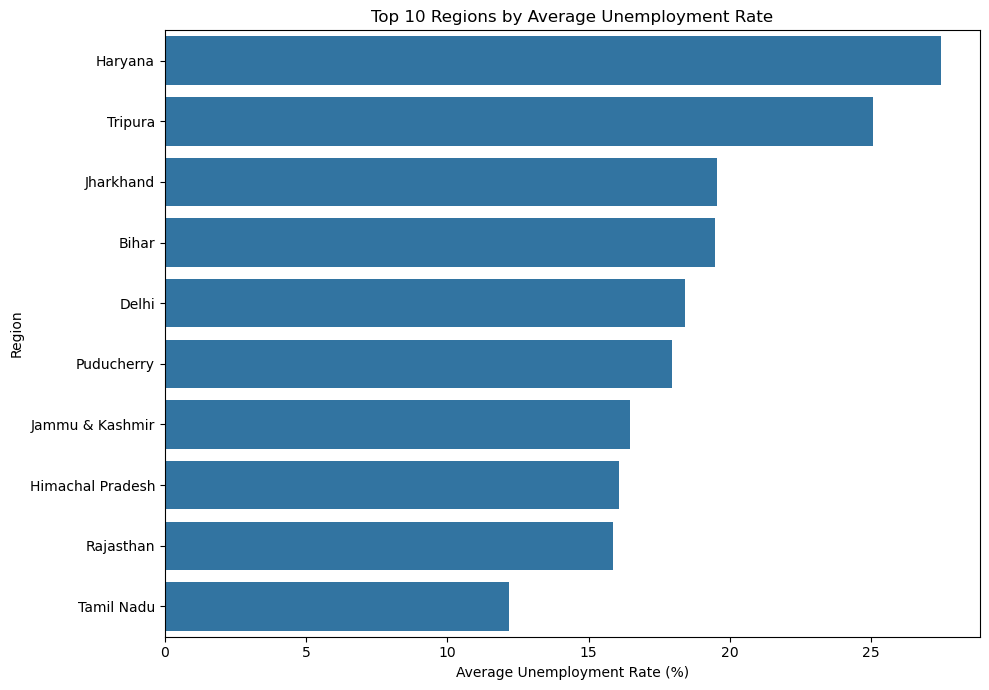

In [17]:
plt.figure(figsize=(10, 7))

sns.barplot(
    x=top_10_states.values,
    y=top_10_states.index
)

plt.title("Top 10 Regions by Average Unemployment Rate")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("Region")

plt.tight_layout()
plt.show()

In [18]:
# Select numerical columns for correlation analysis
correlation_data = df[
    [
        "Estimated Unemployment Rate (%)",
        "Estimated Employed",
        "Estimated Labour Participation Rate (%)"
    ]
]

# Calculate correlation matrix
correlation_matrix = correlation_data.corr()

correlation_matrix

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
Estimated Unemployment Rate (%),1.000000,-0.245176,-0.073540
Estimated Employed,-0.245176,1.000000,-0.047948
Estimated Labour Participation Rate (%),-0.073540,-0.047948,1.000000


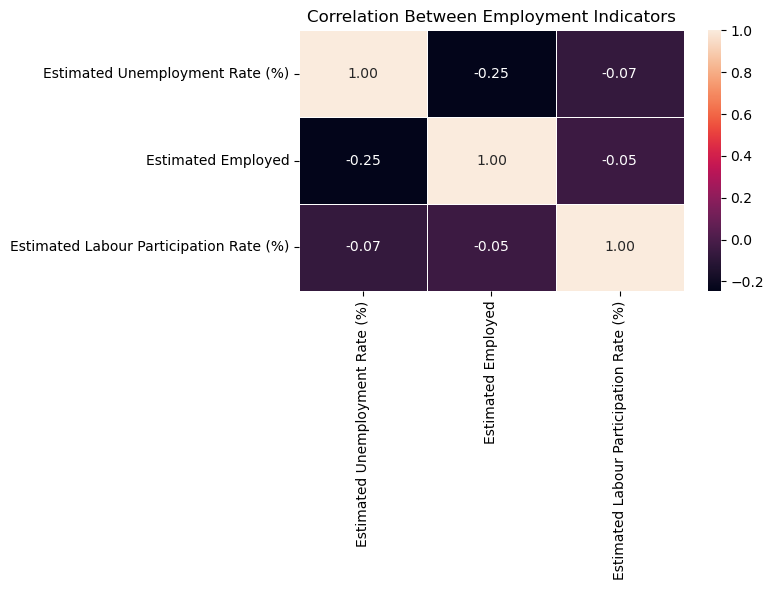

In [19]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Between Employment Indicators")
plt.tight_layout()
plt.show()

In [20]:
# Define pre-COVID and post-COVID periods

pre_covid = df[
    df["Date"] < "2020-03-01"
]

post_covid = df[
    df["Date"] >= "2020-04-01"
]

print("Pre-COVID records:", len(pre_covid))
print("Post-COVID records:", len(post_covid))

Pre-COVID records: 52
Post-COVID records: 188


In [21]:
# Calculate mean values for important indicators
pre_covid_mean = pre_covid[
    [
        "Estimated Unemployment Rate (%)",
        "Estimated Employed",
        "Estimated Labour Participation Rate (%)"
    ]
].mean()

post_covid_mean = post_covid[
    [
        "Estimated Unemployment Rate (%)",
        "Estimated Employed",
        "Estimated Labour Participation Rate (%)"
    ]
].mean()

comparison = pd.DataFrame({
    "Pre-COVID": pre_covid_mean,
    "Post-COVID": post_covid_mean
})

comparison

,Pre-COVID,Post-COVID
Estimated Unemployment Rate (%),9.231346e+00,1.327713e+01
Estimated Employed,1.556273e+07,1.343658e+07
Estimated Labour Participation Rate (%),4.440365e+01,4.063207e+01


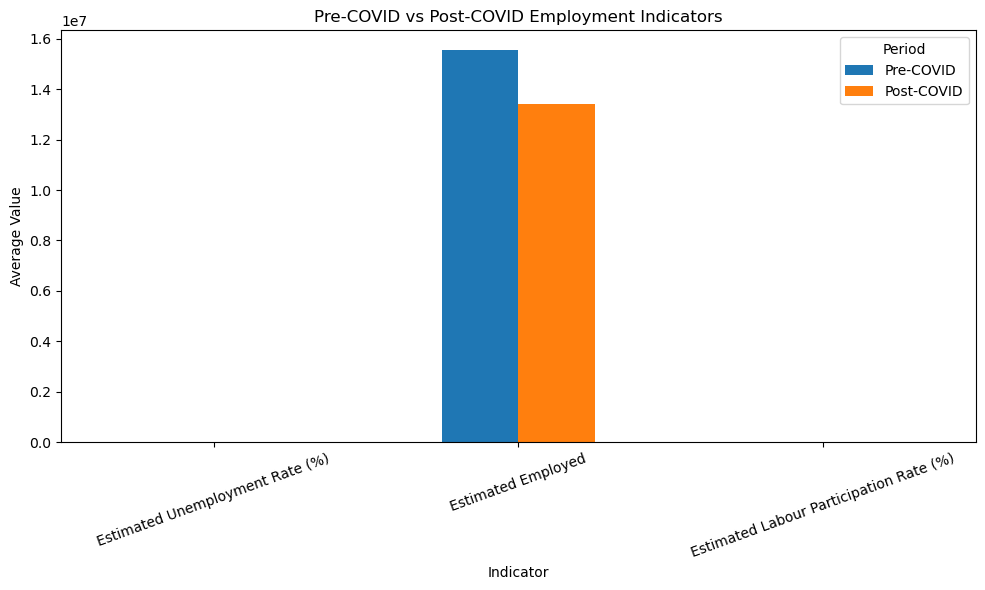

In [22]:
comparison.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Pre-COVID vs Post-COVID Employment Indicators")
plt.xlabel("Indicator")
plt.ylabel("Average Value")
plt.xticks(rotation=20)
plt.legend(title="Period")

plt.tight_layout()
plt.show()

## Overall Insights

1. Unemployment rates varied significantly across different regions of India.

2. The monthly trend shows considerable fluctuations in unemployment during the observed period.

3. The COVID-19 period was associated with a significant rise in unemployment, particularly around the initial lockdown period.

4. Different states experienced different levels of unemployment, indicating regional differences in labour-market conditions.

5. The correlation analysis shows relationships between unemployment, employment, and labour participation, although correlation alone cannot establish causation.

6. The pre-COVID and post-COVID comparison demonstrates that the pandemic period had a substantial impact on employment-related indicators in India.

## Conclusion

This analysis demonstrates how exploratory data analysis can be used to understand unemployment patterns across regions and time. The visualizations and statistical comparisons provide a clearer picture of regional differences and the disruption associated with the COVID-19 period.